In [22]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_FOLDER = Path("output")
OUTPUT_FOLDER.mkdir(exist_ok=True)

In [14]:
df= pd.read_csv("/content/customer_churn_sample.csv")
df.columns = [to_snake_case(col) for col in df.columns]

In [3]:
print("Original shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())


Original shape: (15, 11)
Duplicate rows: 0


In [4]:
df=df.drop_duplicates().copy()

In [6]:
def to_snake_case(column_name: str) -> str:
    value = str(column_name).strip()
    value = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", value)
    value = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", value)
    value = re.sub(r"[^A-Za-z0-9]+", "_", value)
    return value.strip("_").lower()

In [7]:
def grouped_churn_summary(data: pd.DataFrame, group_column: str) -> pd.DataFrame:
    summary = (
        data.groupby(group_column, observed=True)
        .agg(
            customers=("customer_id", "count"),
            churned_customers=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean"),
            average_tenure=("tenure_months", "mean"),
            average_monthly_charges=("monthly_charges", "mean"),
            average_support_tickets=("support_tickets", "mean"),
            total_mrr=("monthly_charges", "sum"),
        )
        .reset_index()
    )

    mrr_loss = (
        data.loc[data["churn_flag"].eq(1)]
        .groupby(group_column, observed=True)["monthly_charges"]
        .sum()
        .rename("mrr_loss")
        .reset_index()
    )

    summary = summary.merge(mrr_loss, on=group_column, how="left")
    summary["mrr_loss"] = summary["mrr_loss"].fillna(0)
    return summary.round(4)

In [10]:
def main() -> None:
    if not df.exists():
        raise FileNotFoundError(f"Dataset not found: {df.resolve()}")

    df = pd.read_csv(df)
    df.columns = [to_snake_case(column) for column in df.columns]

    for column in df.select_dtypes(include="object").columns:
        df[column] = df[column].astype("string").str.strip()

    df = df.replace(
        ["", " ", "NA", "N/A", "na", "n/a", "NULL", "null", "None", "none", "-", "?"],
        np.nan,
    )


In [16]:
numeric_columns = [
        "age",
        "tenure_months",
        "monthly_charges",
        "total_charges",
        "support_tickets",
    ]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
    df[column] = df[column].fillna(df[column].median())

for column in ["gender", "subscription_type", "contract_type", "payment_method", "churn"]:
        df[column] = df[column].fillna("Unknown")

df = df.dropna(subset=["customer_id"]).drop_duplicates().reset_index(drop=True);

df["churn_flag"] = np.where(df["churn"].str.lower().eq("yes"), 1, 0)
df["tenure_band"] = pd.cut(
        df["tenure_months"],
        bins=[-np.inf, 6, 12, 24, np.inf],
        labels=["0-6 months", "7-12 months", "13-24 months", "25+ months"],
    )

In [19]:
contract_summary = grouped_churn_summary(
    df,
    "contract_type",
)

tenure_summary = grouped_churn_summary(
    df,
    "tenure_band",
)

payment_summary = grouped_churn_summary(
    df,
    "payment_method",
)

subscription_summary = grouped_churn_summary(
    df,
    "subscription_type",
)

print("\nChurn Analysis by Contract Type:")
print(contract_summary)

print("\nChurn Analysis by Tenure:")
print(tenure_summary)

print("\nChurn Analysis by Payment Method:")
print(payment_summary)

print("\nChurn Analysis by Subscription Type:")
print(subscription_summary)


# =========================================================
# Correlation analysis
# =========================================================
correlation_columns = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_tickets",
    "churn_flag",
]

correlation_matrix = (
    df[correlation_columns]
    .astype(float)
    .corr()
    .round(2)
)

print("\nCorrelation Matrix:")
print(correlation_matrix)


Churn Analysis by Contract Type:
    contract_type  customers  churned_customers  churn_rate  average_tenure  \
0  Month-to-Month          7                  7         1.0            7.00   
1        One Year          4                  0         0.0           19.75   
2        Two Year          4                  0         0.0           38.50   

   average_monthly_charges  average_support_tickets  total_mrr  mrr_loss  
0                  58.5614                   4.2857     409.93    409.93  
1                  64.9900                   1.5000     259.96      0.00  
2                 149.9900                   0.5000     599.96      0.00  

Churn Analysis by Tenure:
    tenure_band  customers  churned_customers  churn_rate  average_tenure  \
0    0-6 months          4                  4         1.0            3.75   
1   7-12 months          2                  2         1.0           10.00   
2  13-24 months          5                  1         0.2           18.60   
3    25+ month

In [20]:
correlation_columns = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_tickets",
    "churn_flag",
]

correlation_matrix = (
    df[correlation_columns]
    .astype(float)
    .corr()
    .round(2)
)

print("\nCorrelation Matrix:")
print(correlation_matrix)



Correlation Matrix:
                  age  tenure_months  monthly_charges  total_charges  \
age              1.00           0.85             0.70           0.76   
tenure_months    0.85           1.00             0.87           0.96   
monthly_charges  0.70           0.87             1.00           0.95   
total_charges    0.76           0.96             0.95           1.00   
support_tickets -0.84          -0.86            -0.71          -0.73   
churn_flag      -0.73          -0.80            -0.59          -0.66   

                 support_tickets  churn_flag  
age                        -0.84       -0.73  
tenure_months              -0.86       -0.80  
monthly_charges            -0.71       -0.59  
total_charges              -0.73       -0.66  
support_tickets             1.00        0.88  
churn_flag                  0.88        1.00  


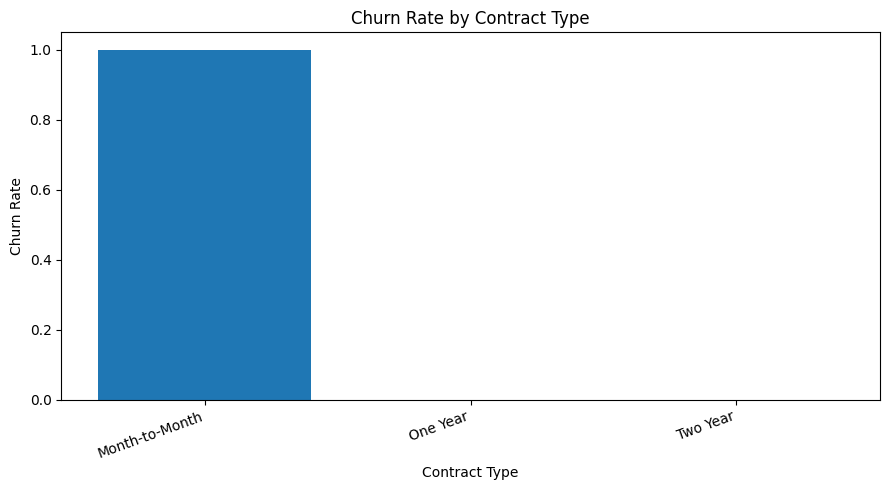

In [23]:
plt.figure(figsize=(9, 5))

plt.bar(
    contract_summary["contract_type"],
    contract_summary["churn_rate"],
)

plt.title(
    "Churn Rate by Contract Type"
)

plt.xlabel(
    "Contract Type"
)

plt.ylabel(
    "Churn Rate"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "churn_rate_by_contract.png",
    dpi=200,
)

plt.show()

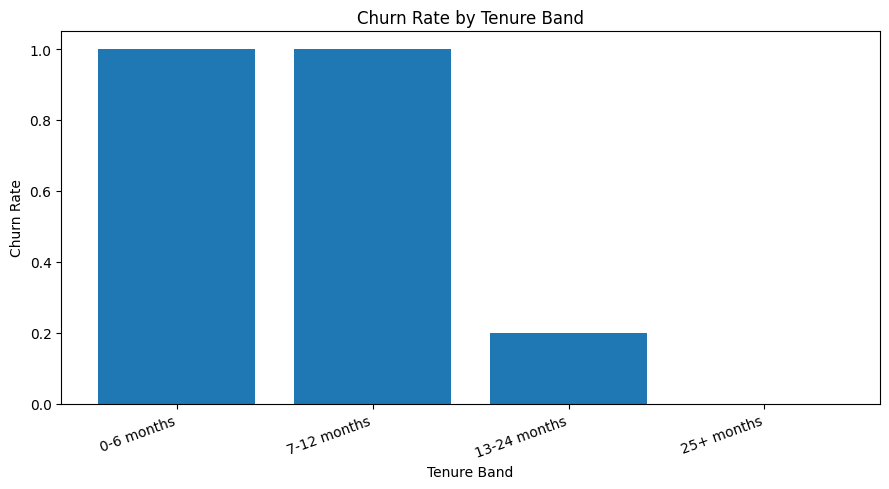

In [24]:
plt.figure(figsize=(9, 5))

plt.bar(
    tenure_summary["tenure_band"].astype(str),
    tenure_summary["churn_rate"],
)

plt.title(
    "Churn Rate by Tenure Band"
)

plt.xlabel(
    "Tenure Band"
)

plt.ylabel(
    "Churn Rate"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "churn_rate_by_tenure.png",
    dpi=200,
)

plt.show()



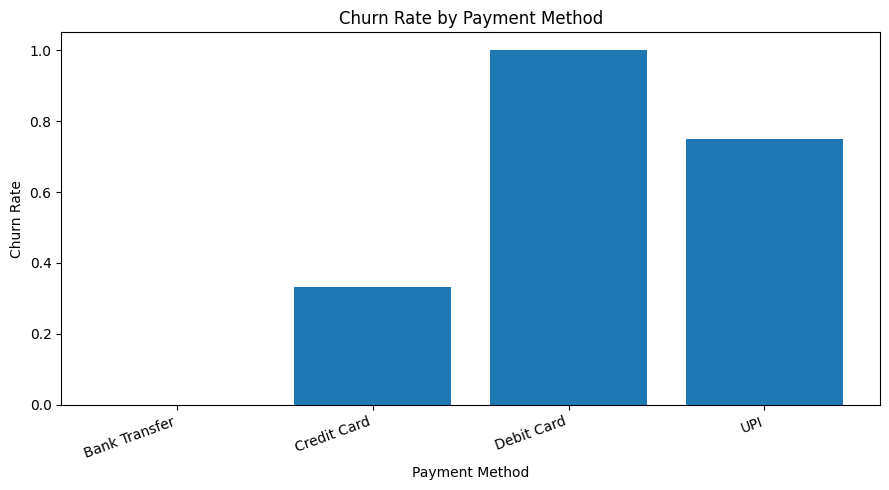

In [26]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_summary["payment_method"],
    payment_summary["churn_rate"],
)

plt.title(
    "Churn Rate by Payment Method"
)

plt.xlabel(
    "Payment Method"
)

plt.ylabel(
    "Churn Rate"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "churn_rate_by_payment_method.png",
    dpi=200,
)

plt.show()




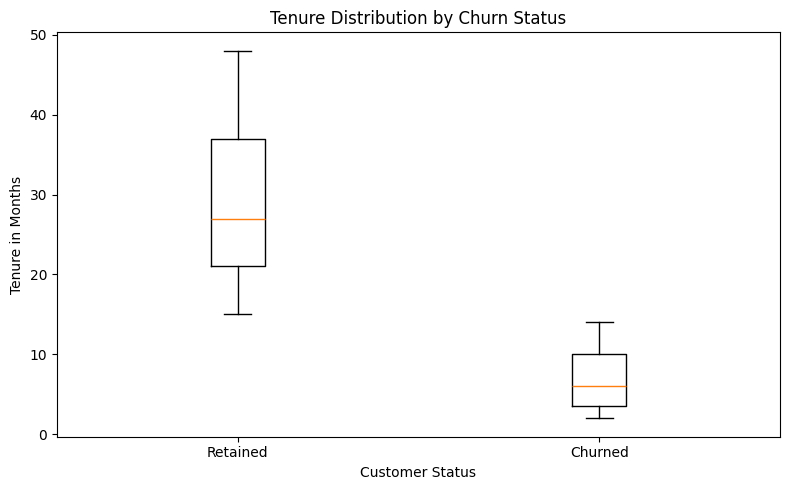

In [27]:
# =========================================================
# Visualization 4: Tenure boxplot by churn
# =========================================================
retained_tenure = df.loc[
    df["churn_flag"] == 0,
    "tenure_months",
].astype(float)

churned_tenure = df.loc[
    df["churn_flag"] == 1,
    "tenure_months",
].astype(float)

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        retained_tenure,
        churned_tenure,
    ],
    tick_labels=[
        "Retained",
        "Churned",
    ],
)

plt.title(
    "Tenure Distribution by Churn Status"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Tenure in Months"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "tenure_boxplot_by_churn.png",
    dpi=200,
)

plt.show()

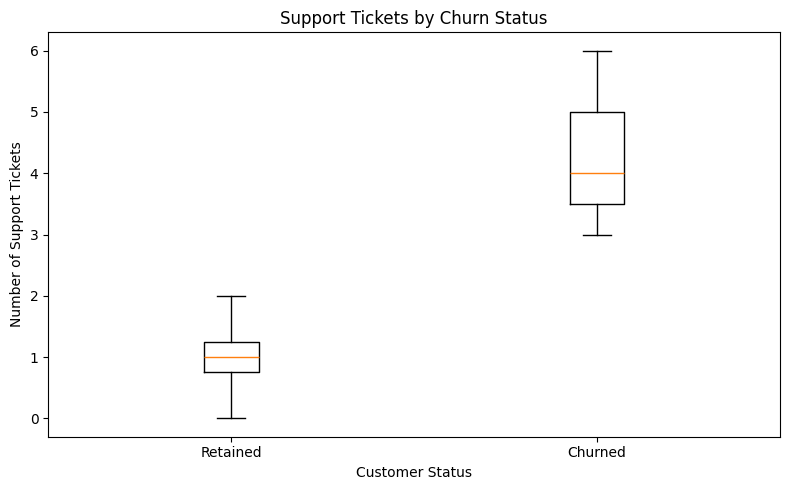

In [28]:
retained_tickets = df.loc[
    df["churn_flag"] == 0,
    "support_tickets",
].astype(float)

churned_tickets = df.loc[
    df["churn_flag"] == 1,
    "support_tickets",
].astype(float)

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        retained_tickets,
        churned_tickets,
    ],
    tick_labels=[
        "Retained",
        "Churned",
    ],
)

plt.title(
    "Support Tickets by Churn Status"
)

plt.xlabel(
    "Customer Status"
)

plt.ylabel(
    "Number of Support Tickets"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "support_tickets_boxplot.png",
    dpi=200,
)

plt.show()


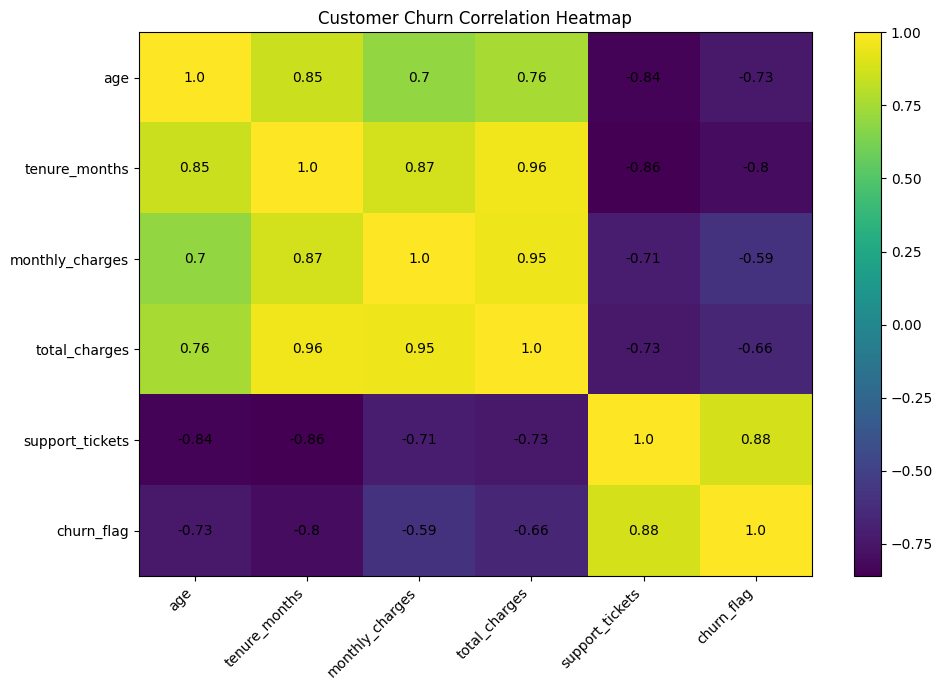

In [29]:
plt.figure(figsize=(10, 7))

heatmap = plt.imshow(
    correlation_matrix.to_numpy(),
    aspect="auto",
)

plt.colorbar(
    heatmap
)

plt.xticks(
    range(
        len(correlation_matrix.columns)
    ),
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(
        len(correlation_matrix.index)
    ),
    correlation_matrix.index,
)

for row_index in range(
    correlation_matrix.shape[0]
):
    for column_index in range(
        correlation_matrix.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            correlation_matrix.iloc[
                row_index,
                column_index,
            ],
            ha="center",
            va="center",
        )

plt.title(
    "Customer Churn Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FOLDER
    / "correlation_heatmap.png",
    dpi=200,
)

plt.show()

In [32]:
total_customers = len(df)
churned_customers = df["churn_flag"].sum()
retained_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers
total_mrr = df["monthly_charges"].sum()
mrr_loss = df.loc[df["churn_flag"] == 1, "monthly_charges"].sum()
mrr_loss_percentage = mrr_loss / total_mrr
annualized_revenue_loss = mrr_loss * 12

average_clv = df["total_charges"].mean()
average_churned_clv = df.loc[df["churn_flag"] == 1, "total_charges"].mean()
average_retained_clv = df.loc[df["churn_flag"] == 0, "total_charges"].mean()

average_churned_tenure = df.loc[df["churn_flag"] == 1, "tenure_months"].mean()
average_retained_tenure = df.loc[df["churn_flag"] == 0, "tenure_months"].mean()

average_churned_tickets = df.loc[df["churn_flag"] == 1, "support_tickets"].mean()
average_retained_tickets = df.loc[df["churn_flag"] == 0, "support_tickets"].mean()

kpi_data = pd.DataFrame(
    {
        "Metric": [
            "Total Customers",
            "Churned Customers",
            "Retained Customers",
            "Churn Rate",
            "Total MRR",
            "MRR Loss",
            "MRR Loss Percentage",
            "Annualized Revenue Loss",
            "Average Historical CLV",
            "Average Churned CLV",
            "Average Retained CLV",
            "Average Churned Tenure",
            "Average Retained Tenure",
            "Average Churned Support Tickets",
            "Average Retained Support Tickets",
        ],
        "Value": [
            total_customers,
            churned_customers,
            retained_customers,
            churn_rate,
            total_mrr,
            mrr_loss,
            mrr_loss_percentage,
            annualized_revenue_loss,
            average_clv,
            average_churned_clv,
            average_retained_clv,
            average_churned_tenure,
            average_retained_tenure,
            average_churned_tickets,
            average_retained_tickets,
        ],
    }
)

print("\nCustomer Churn KPIs:")
print(kpi_data)



Customer Churn KPIs:
                              Metric        Value
0                    Total Customers    15.000000
1                  Churned Customers     7.000000
2                 Retained Customers     8.000000
3                         Churn Rate     0.466667
4                          Total MRR  1269.850000
5                           MRR Loss   409.930000
6                MRR Loss Percentage     0.322818
7            Annualized Revenue Loss  4919.160000
8             Average Historical CLV  2088.478667
9                Average Churned CLV   444.215714
10              Average Retained CLV  3527.208750
11            Average Churned Tenure     7.000000
12           Average Retained Tenure    29.125000
13   Average Churned Support Tickets     4.285714
14  Average Retained Support Tickets     1.000000


In [33]:
recommendations = [
    {
        "Priority": 1,
        "Recommendation": (
            "Convert Month-to-Month customers "
            "to annual contracts."
        ),
    },
    {
        "Priority": 2,
        "Recommendation": (
            "Create 30-day, 60-day and 90-day "
            "onboarding checkpoints."
        ),
    },
    {
        "Priority": 3,
        "Recommendation": (
            "Trigger retention intervention when "
            "support tickets reach 3 or more."
        ),
    },
    {
        "Priority": 4,
        "Recommendation": (
            "Provide autopay incentives and payment "
            "failure alerts."
        ),
    },
    {
        "Priority": 5,
        "Recommendation": (
            "Provide loyalty rewards to customers "
            "after 12 months."
        ),
    },
]

recommendation_df = pd.DataFrame(
    recommendations
)

print("\nBusiness Recommendations:")
print(recommendation_df)


# =========================================================
# Export output files
# =========================================================
df.to_csv(
    OUTPUT_FOLDER
    / "customer_churn_analysis_data.csv",
    index=False,
)

kpi_data.to_csv(
    OUTPUT_FOLDER
    / "customer_churn_kpis.csv",
    index=False,
)

contract_summary.to_csv(
    OUTPUT_FOLDER
    / "churn_by_contract.csv",
    index=False,
)

tenure_summary.to_csv(
    OUTPUT_FOLDER
    / "churn_by_tenure.csv",
    index=False,
)

payment_summary.to_csv(
    OUTPUT_FOLDER
    / "churn_by_payment_method.csv",
    index=False,
)

subscription_summary.to_csv(
    OUTPUT_FOLDER
    / "churn_by_subscription_type.csv",
    index=False,
)

correlation_matrix.to_csv(
    OUTPUT_FOLDER
    / "correlation_matrix.csv",
)

recommendation_df.to_csv(
    OUTPUT_FOLDER
    / "business_recommendations.csv",
    index=False,
)


# =========================================================
# Final output
# =========================================================
print("\nCustomer Churn Analysis Completed")

print(
    f"Total Customers: "
    f"{total_customers}"
)

print(
    f"Churned Customers: "
    f"{churned_customers}"
)

print(
    f"Churn Rate: "
    f"{churn_rate:.2%}"
)

print(
    f"Total MRR: "
    f"₹{total_mrr:,.2f}"
)

print(
    f"MRR Loss: "
    f"₹{mrr_loss:,.2f}"
)

print(
    f"MRR Loss Percentage: "
    f"{mrr_loss_percentage:.2%}"
)

print(
    f"Annualized Revenue Loss: "
    f"₹{annualized_revenue_loss:,.2f}"
)

print(
    f"Average Historical CLV: "
    f"₹{average_clv:,.2f}"
)

print(
    f"\nAll files saved inside: "
    f"{OUTPUT_FOLDER.resolve()}"
)


Business Recommendations:
   Priority                                     Recommendation
0         1  Convert Month-to-Month customers to annual con...
1         2  Create 30-day, 60-day and 90-day onboarding ch...
2         3  Trigger retention intervention when support ti...
3         4  Provide autopay incentives and payment failure...
4         5  Provide loyalty rewards to customers after 12 ...

Customer Churn Analysis Completed
Total Customers: 15
Churned Customers: 7
Churn Rate: 46.67%
Total MRR: ₹1,269.85
MRR Loss: ₹409.93
MRR Loss Percentage: 32.28%
Annualized Revenue Loss: ₹4,919.16
Average Historical CLV: ₹2,088.48

All files saved inside: /content/output
